<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Credit Model

<font color='black'>

- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Luis Fernando Márquez Bañuelos

In [1]:
import os
import shap
import warnings
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
warnings.filterwarnings('ignore')

## <font color='cornflowerblue'> Functions

In [2]:
def curva_roc(probabilidades: np.ndarray, y_test: np.ndarray) -> float:
        """
        Analyzes the ROC curve to find the optimal threshold and visualizes it.

        Args:
                probabilidades (np.ndarray): Predicted probabilities of the positive class.
                y_test (np.ndarray): True binary labels for the test set.

        Returns:
                float: Optimal threshold value.
        """
        fpr, tpr, thresholds = roc_curve(y_score=probabilidades, y_true=y_test)

        distances   = np.sqrt(fpr**2 + (1 - tpr)**2)
        best_idx    = np.argmin(distances)
        best_thr    = thresholds[best_idx]
        best_fpr    = fpr[best_idx]
        best_tpr    = tpr[best_idx]
        auc_score   = roc_auc_score(y_test, probabilidades)

        fig, ax = plt.subplots(figsize=(9, 5))

        # Área bajo la curva sombreada
        ax.fill_between(fpr, tpr, alpha=0.08, color='#2E86AB')

        ax.plot(fpr, tpr, color='#2E86AB', lw=2,
                label=f'AUC = {auc_score:.3f}')
        ax.plot([0, 1], [0, 1], color='#E84855', lw=1.5,
                linestyle='--', label='Random classifier')

        # Líneas guía al mejor threshold
        ax.plot([best_fpr, best_fpr], [0, best_tpr],
                color='#F4A261', lw=1, linestyle=':')
        ax.plot([0, best_fpr], [best_tpr, best_tpr],
                color='#F4A261', lw=1, linestyle=':')

        # Estrella
        ax.scatter(best_fpr, best_tpr, marker='*', s=400,
                color='#F4A261', zorder=5,
                label=f'Best threshold = {best_thr:.3f}\n'
                        f'FPR={best_fpr:.3f}  TPR={best_tpr:.3f}')

        ax.set_xlim(-0.01, 1.01)
        ax.set_ylim(-0.01, 1.01)
        ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
        ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
        ax.set_title('ROC Curve — Credit Default XGBoost',
                        fontsize=13, fontweight='bold', pad=12)
        ax.legend(fontsize=10, framealpha=0.9, loc='lower right')

        plt.tight_layout()
        plt.show()

        return best_thr


def lgd_hipotecario(ead: np.ndarray, 
                    property_value: np.ndarray,
                    haircut: float = 0.25) -> np.ndarray:
        """
        Computes LGD for mortgage loans based on collateral recovery.

        At default, the bank recovers the property value minus execution costs
        (legal fees, foreclosure costs, fire-sale discount) modeled as a haircut.

        Recovery = min(EAD, VALUE * (1 - haircut))
        LGD = max(0, 1 - Recovery / EAD)

        Args:
                ead (np.ndarray): Outstanding balance at default (EAD), shape (n,).
                property_value (np.ndarray): Appraised value of the mortgaged property, shape (n,).
                haircut (float): Foreclosure cost as fraction of property value (default 25%).

        Returns:
                np.ndarray: LGD values in [0, 1], shape (n,).
        """
        net_recovery = property_value * (1 - haircut)
        # Bank can only recover up to what is owed
        actual_recovery = np.minimum(ead, net_recovery)
        lgd = 1 - (actual_recovery / ead)
        return np.clip(lgd, 0, 1)


def amortization(principal: float | pd.Series, annual_rate: float, months: int) -> float:
    """
    Generates an amortization schedule for a loan.

    Args:
        principal (float | pd.Series): The initial amount of the loan.
        annual_rate (float): The annual interest rate.
        months (int): The total number of monthly payments.

    Returns:
        float: The total amount paid over the life of the loan.
    """
    annual_rate = annual_rate / 100  # Convert percentage to decimal
    monthly_rate = annual_rate / 12
    payment = principal * (monthly_rate / (1 - (1 + monthly_rate) ** -months))

    return payment * months

## <font color='cornflowerblue'> Data

In [3]:
"""path = kagglehub.dataset_download("arunbhuta/credit-analysis-probability-of-default")
os.listdir(path)
data = pd.read_csv(f"{path}/cr_loan2.csv")
data"""

'path = kagglehub.dataset_download("arunbhuta/credit-analysis-probability-of-default")\nos.listdir(path)\ndata = pd.read_csv(f"{path}/cr_loan2.csv")\ndata'

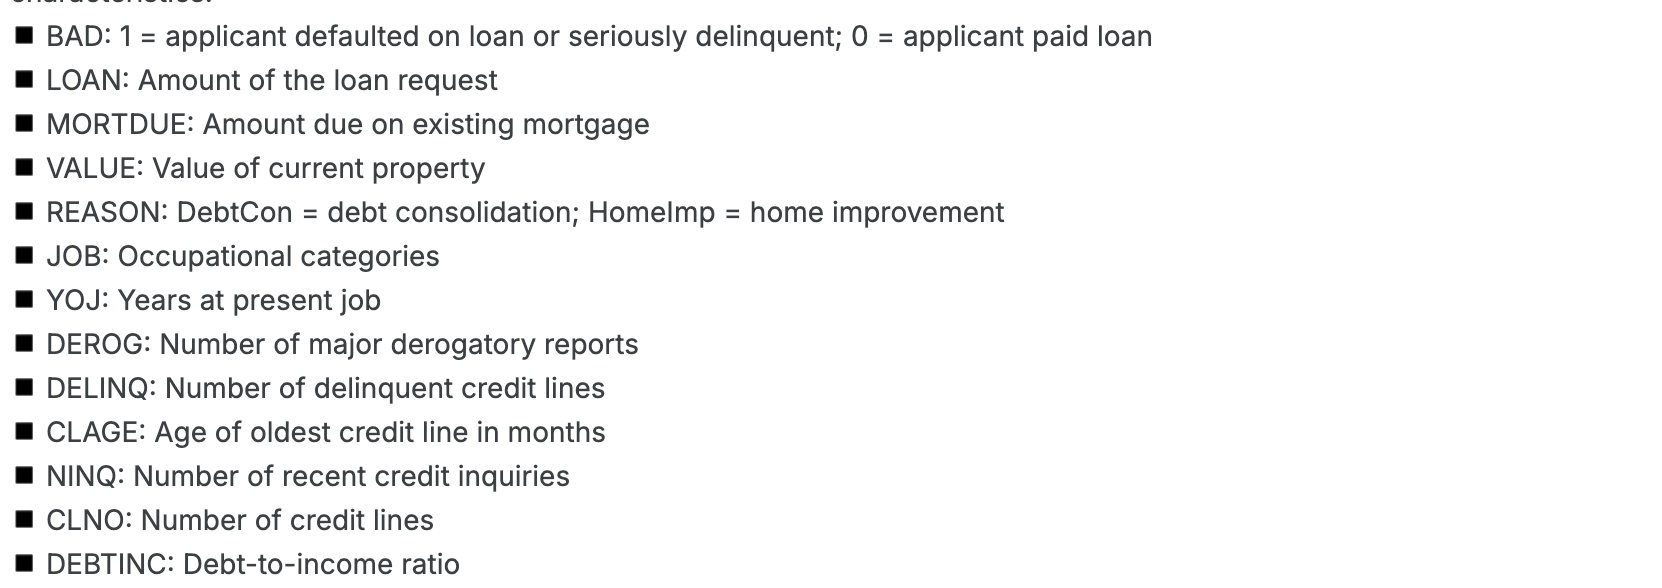

In [4]:
# NOTE: LOAN represents the new credit requested by the applicant.
# We assume the existing mortgage (MORTDUE) is already held by our bank.
# Therefore:
#   - EAD = MORTDUE (current outstanding exposure)
#   - LOAN is retained only as a feature for PD estimation (LTV, CLTV)
#   - LOAN does not enter the EL calculation

# Load the HMEQ dataset from Kaggle
path = kagglehub.dataset_download("lchipham/home-equity-loan-default")
os.listdir(path)
data = pd.read_csv(f"{path}/hmeq.csv")
data

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882


## <font color='cornflowerblue'> Feature Engineering

In [5]:
# Preprocess categorical variables using one-hot encoding
categorical_cols = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_cols)
data

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_DebtCon,REASON_HomeImp,JOB_Mgr,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,False,True,False,False,True,False,False,False
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,False,True,False,False,True,False,False,False
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,False,True,False,False,True,False,False,False
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,True,False,False,False,True,False,False,False
5956,0,89000,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,True,False,False,False,True,False,False,False
5957,0,89200,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,True,False,False,False,True,False,False,False
5958,0,89800,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,True,False,False,False,True,False,False,False


In [6]:
# Nivel de apalancamiento total
data['TOTAL_DEBT'] = data['LOAN'] + data['MORTDUE']

# Loan-to-Value: qué tan apalancado está el crédito vs. el inmueble
data['LTV'] = data['LOAN'] / data['VALUE']

# Combined LTV: suma deuda nueva + deuda hipotecaria existente sobre el valor
data['CLTV'] = data['TOTAL_DEBT'] / data['VALUE']

# Equity del propietario: qué tanto del inmueble es "suyo"
data['HOME_EQUITY'] = data['VALUE'] - data['MORTDUE']

# Equity ratio
data['EQUITY_RATIO'] = data['HOME_EQUITY'] / data['VALUE']

# Ratio de líneas delinquentes sobre total
data['DELINQ_RATIO'] = data['DELINQ'] / (data['CLNO'] + 1)  # +1 evita división por 0

# Equity negativo (underwater): deuda > valor del inmueble
data['UNDERWATER'] = (data['TOTAL_DEBT'] > data['VALUE']).astype(int)

data

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,JOB_ProfExe,JOB_Sales,JOB_Self,TOTAL_DEBT,LTV,CLTV,HOME_EQUITY,EQUITY_RATIO,DELINQ_RATIO,UNDERWATER
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,...,False,False,False,26960.0,0.028187,0.690839,13165.0,0.337348,0.000000,0
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,...,False,False,False,71353.0,0.019006,1.043173,-1653.0,-0.024167,0.133333,1
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,...,False,False,False,15000.0,0.089820,0.898204,3200.0,0.191617,0.000000,0
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,...,False,False,False,99500.0,0.015179,0.888393,14200.0,0.126786,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,...,False,False,False,146164.0,0.985752,1.620713,32921.0,0.365039,0.000000,1
5956,0,89000,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,...,False,False,False,143576.0,0.957638,1.544874,38361.0,0.412763,0.000000,1
5957,0,89200,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,...,False,False,False,143245.0,0.959924,1.541529,38879.0,0.418396,0.000000,1
5958,0,89800,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,...,False,False,False,140170.0,0.977564,1.525892,41491.0,0.451672,0.000000,1


In [7]:
# Defining the target variable
target = 'BAD'

X = data.copy()
# Drop target and features that may cause data leakage or are not relevant for PD estimation
X = X.drop(columns=[target, 'HOME_EQUITY', 'TOTAL_DEBT'])
y = data[target]

# Split the dataset into training and testing sets with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## <font color='cornflowerblue'> Model: XGBoost

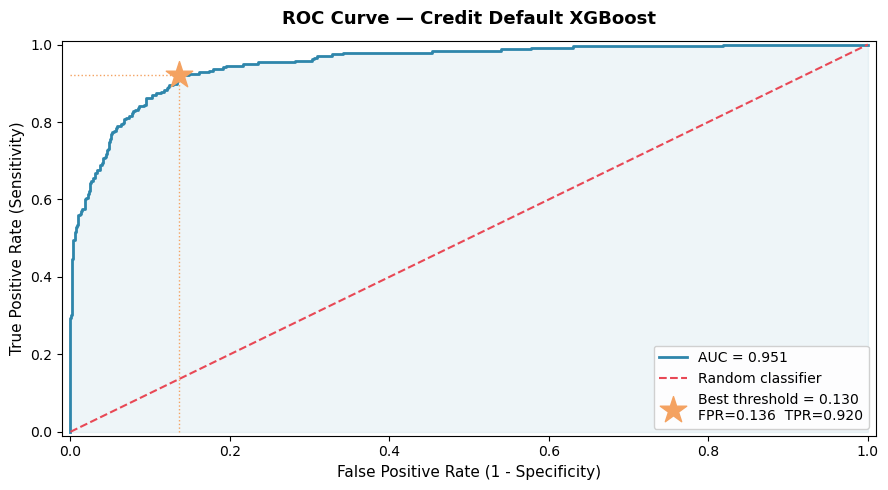

In [8]:
# XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

# Predictions and probabilities
y_proba_log = model.predict_proba(X_test)[:, 1]
best_thr = curva_roc(y_proba_log, y_test)

In [9]:
# Create a test set DataFrame for analysis
data_test = pd.concat([X_test, y_test], axis=1)

data_test['LGD'] = lgd_hipotecario(
    ead            = data_test['MORTDUE'].values,
    property_value = data_test['VALUE'].values,
    haircut        = 0.25
)

data_test

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,...,JOB_ProfExe,JOB_Sales,JOB_Self,LTV,CLTV,EQUITY_RATIO,DELINQ_RATIO,UNDERWATER,BAD,LGD
4798,25100,41314.0,71357.0,19.0,0.0,0.0,183.631428,1.0,22.0,33.665534,...,False,False,False,0.351752,0.930729,0.421024,0.000000,0,0,0.000000
3716,19600,33284.0,61824.0,14.0,0.0,0.0,119.473073,1.0,17.0,37.784524,...,False,False,False,0.317029,0.855396,0.461633,0.000000,0,0,0.000000
1472,11000,54641.0,65705.0,5.0,0.0,0.0,323.192928,0.0,10.0,33.299628,...,False,False,False,0.167415,0.999026,0.168389,0.000000,0,0,0.098136
1050,9600,45240.0,60136.0,2.0,0.0,1.0,83.066751,0.0,19.0,38.454300,...,False,False,False,0.159638,0.911933,0.247705,0.050000,0,0,0.003050
87,4000,58000.0,69440.0,3.5,0.0,1.0,168.666667,0.0,18.0,NaN,...,False,False,False,0.057604,0.892857,0.164747,0.052632,0,1,0.102069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4053,21200,62067.0,104579.0,13.0,0.0,0.0,143.364530,0.0,14.0,36.107667,...,False,False,False,0.202718,0.796211,0.406506,0.000000,0,0,0.000000
2825,15800,51163.0,157644.0,19.0,0.0,0.0,239.224789,0.0,28.0,20.747521,...,True,False,False,0.100226,0.424774,0.675452,0.000000,0,0,0.000000
1383,10700,50210.0,64838.0,9.0,0.0,0.0,95.039168,2.0,34.0,40.396233,...,False,False,False,0.165027,0.939418,0.225608,0.000000,0,0,0.031498
4111,21500,141688.0,184241.0,8.0,0.0,0.0,311.426128,0.0,16.0,44.590155,...,False,False,False,0.116695,0.885731,0.230964,0.000000,0,0,0.024753


In [10]:
# Add probabilities and calculate expected loss
data_test['default_proba'] = y_proba_log
data_test['EL_pct'] = data_test['default_proba'] * data_test['LGD']
data_test['EL_amount'] = data_test['default_proba'] * data_test['LGD'] * data_test['MORTDUE']

# Results
portfolio = data_test['MORTDUE'].sum()
expected_loss_portfolio = data_test['EL_amount'].sum()

print(f"Total Portfolio Outstanding Debt: ${portfolio:,.2f}")
print(f"Expected Loss for the Portfolio: ${expected_loss_portfolio:,.2f}")
print(f"Expected Loss as % of Portfolio: {expected_loss_portfolio / portfolio:.2%}")

Total Portfolio Outstanding Debt: $81,124,470.00
Expected Loss for the Portfolio: $634,744.61
Expected Loss as % of Portfolio: 0.78%


In [11]:
# Classify clients as predicted default (1) or non-default (0) based on the best threshold
data_test['model_prediction'] = (data_test['default_proba'] >= best_thr).astype(int)

# Computing actual loss based on model predictions. Where the model output was 0 (non-default) but the actual default was 1, we sum the outstanding debt to get the actual loss.
actual_loss = data_test[(data_test['model_prediction'] == 0) & (data_test['BAD'] == 1)]['MORTDUE'].sum()
print(f"Actual Loss for the Portfolio: ${actual_loss:,.2f}")
print(f"Actual Loss as % of Portfolio: {actual_loss / portfolio:.2%}\n")

# Computing opportunity cost based on model predictions. Where the model output was 1 (predicted default) but the actual default was 0, we sum the loan amount to get the opportunity cost.
opportunity_cost = data_test[(data_test['model_prediction'] == 1) & (data_test['BAD'] == 0)]['MORTDUE'].sum()
print(f"Opportunity Cost for the Portfolio: ${opportunity_cost:,.2f}")
print(f"Opportunity Cost as % of Portfolio: {opportunity_cost / portfolio:.2%}")

Actual Loss for the Portfolio: $1,464,852.00
Actual Loss as % of Portfolio: 1.81%

Opportunity Cost for the Portfolio: $7,069,703.00
Opportunity Cost as % of Portfolio: 8.71%


In [12]:
# Classify clients as predicted default (1) or non-default (0) based on the best threshold
data_test['model_prediction'] = (data_test['default_proba'] >= best_thr).astype(int)

# Computing actual loss based on model predictions. Where the model output was 0 (non-default) but the actual default was 1, we sum the outstanding debt to get the actual loss.
actual_loss = data_test[(data_test['model_prediction'] == 0) & (data_test['BAD'] == 1)]['MORTDUE'].sum()
print(f"Actual Loss for the Portfolio: ${actual_loss:,.2f}")
print(f"Actual Loss as % of Portfolio: {actual_loss / portfolio:.2%}\n")

# Loans requested that were predicted as default but were actually non-default (opportunity cost)
loans = data_test[(data_test['model_prediction'] == 1) & (data_test['BAD'] == 0)].LOAN
opportunity_cost = np.sum(amortization(principal=loans, annual_rate=11.5040, months=240))
print(f"Opportunity Cost for the Portfolio: ${opportunity_cost:,.2f}")
print(f"Opportunity Cost as % of Portfolio: {opportunity_cost / portfolio:.2%}")

Actual Loss for the Portfolio: $1,464,852.00
Actual Loss as % of Portfolio: 1.81%

Opportunity Cost for the Portfolio: $5,711,310.63
Opportunity Cost as % of Portfolio: 7.04%


In [13]:
bins   = [0, 0.05, 0.15, 0.30, 1.0]
labels = ['Low', 'Medium', 'High', 'Very High']
data_test['risk_bucket'] = pd.cut(data_test['default_proba'], bins=bins, labels=labels)

resumen = data_test.groupby('risk_bucket', observed=True).agg(
    n_creditos    = ('EL_amount', 'count'),
    EAD_total     = ('MORTDUE', 'sum'),
    EL_total      = ('EL_amount', 'sum'),
    PD_promedio   = ('default_proba', 'mean'),
    LGD_promedio  = ('LGD', 'mean'),
).assign(EL_pct=lambda x: x['EL_total'] / x['EAD_total'])

resumen

,n_creditos,EAD_total,EL_total,PD_promedio,LGD_promedio,EL_pct
risk_bucket,,,,,,
Low,553,42735426.0,53262.241990,0.025769,0.030734,0.001246
Medium,244,17616502.0,153208.104461,0.083424,0.065220,0.008697
High,71,4827229.0,38120.176033,0.218083,0.028254,0.007897
Very High,209,15945313.0,390154.087840,0.670472,0.033121,0.024468


              precision    recall  f1-score   support

           0       0.98      0.86      0.92       954
           1       0.63      0.92      0.75       238

    accuracy                           0.88      1192
   macro avg       0.80      0.89      0.83      1192
weighted avg       0.91      0.88      0.88      1192



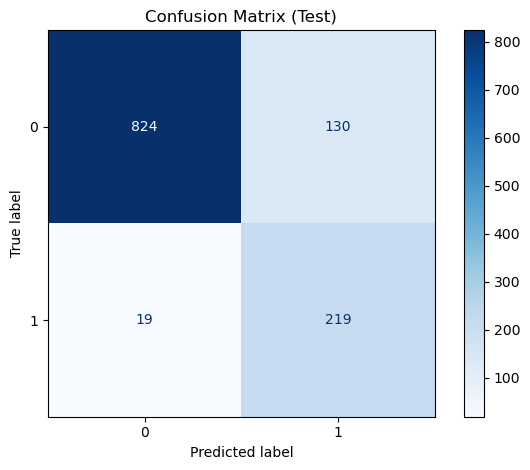

In [14]:
# Evaluation
print(classification_report(y_test, data_test['model_prediction']))

ConfusionMatrixDisplay.from_predictions(
    y_test, data_test['model_prediction'],
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

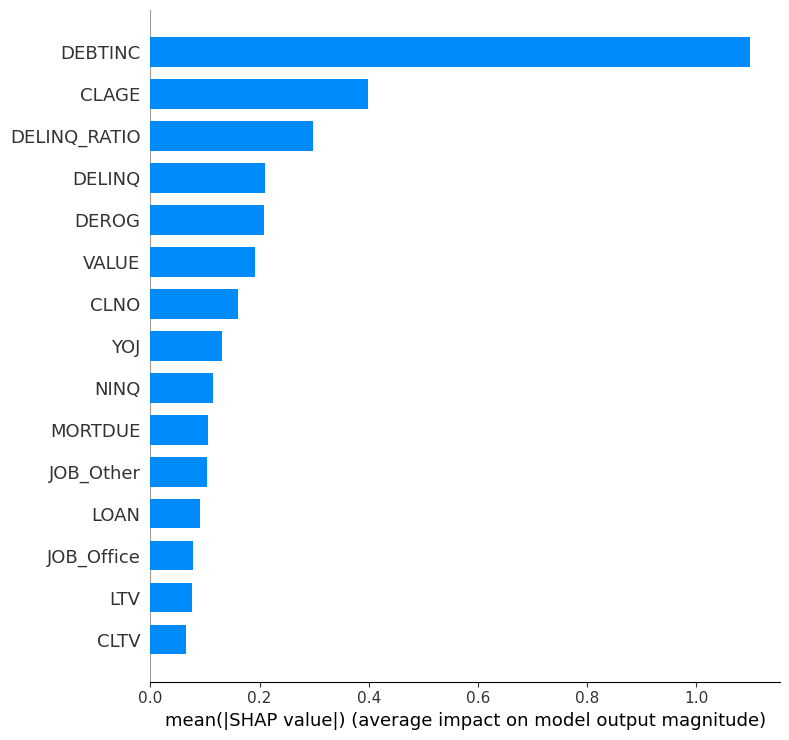

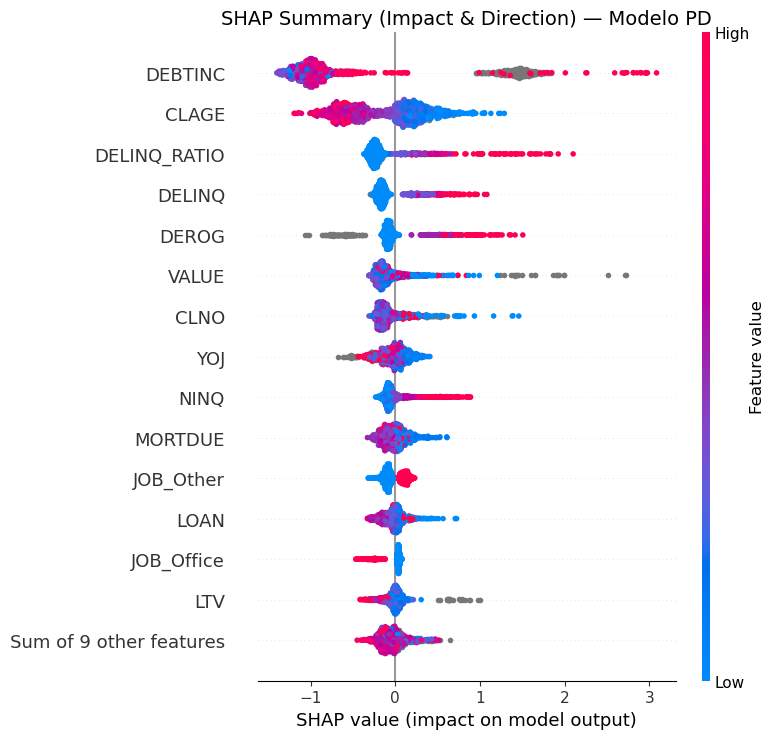

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15,
                  title='SHAP Feature Importance — Modelo PD Hipotecario')

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary (Impact & Direction) — Modelo PD", fontsize=14)

plt.tight_layout()
plt.show()